In [52]:
# ==========================================================
# FASE 3: PREDICTIVE ANALYTICS (SEASONAL SALES FORECASTING)
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Mengatur tema grafik
sns.set_theme(style="whitegrid")

# memuat data seasonal_sales_trend.csv
file_trend = '../data/Result_Data_Query/04_seasonal_sales_trend.csv'
df_trend = pd.read_csv(file_trend)

In [53]:
# Cek tabel data hasil import
df_trend

,year,month,category,total_volume_sold
0,2015,1,Bikes,184
1,2015,2,Bikes,165
2,2015,3,Bikes,198
3,2015,4,Bikes,204
4,2015,5,Bikes,206
5,2015,6,Bikes,212
6,2015,7,Bikes,247
7,2015,8,Bikes,278
8,2015,9,Bikes,196
9,2015,10,Bikes,223


In [54]:
# Cek informasi tabel data hasil import
df_trend.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   year               54 non-null     int64 
 1   month              54 non-null     int64 
 2   category           54 non-null     object
 3   total_volume_sold  54 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.8+ KB


In [55]:
# Menetahui statistik deskriptif dari data
df_trend.describe()

,year,month,total_volume_sold
count,54.000000,54.000000,54.000000
mean,2016.111111,6.166667,1558.777778
std,0.743948,3.468184,1879.883785
min,2015.000000,1.000000,165.000000
25%,2016.000000,3.000000,269.750000
50%,2016.000000,6.000000,908.500000
75%,2017.000000,9.000000,1199.250000
max,2017.000000,12.000000,5856.000000


=== 5 Baris Pertama Data Penjualan Bulanan (Siap Prediksi) ===


,total_volume_sold
order_date,
2015-01-01,184
2015-02-01,165
2015-03-01,198
2015-04-01,204
2015-05-01,206


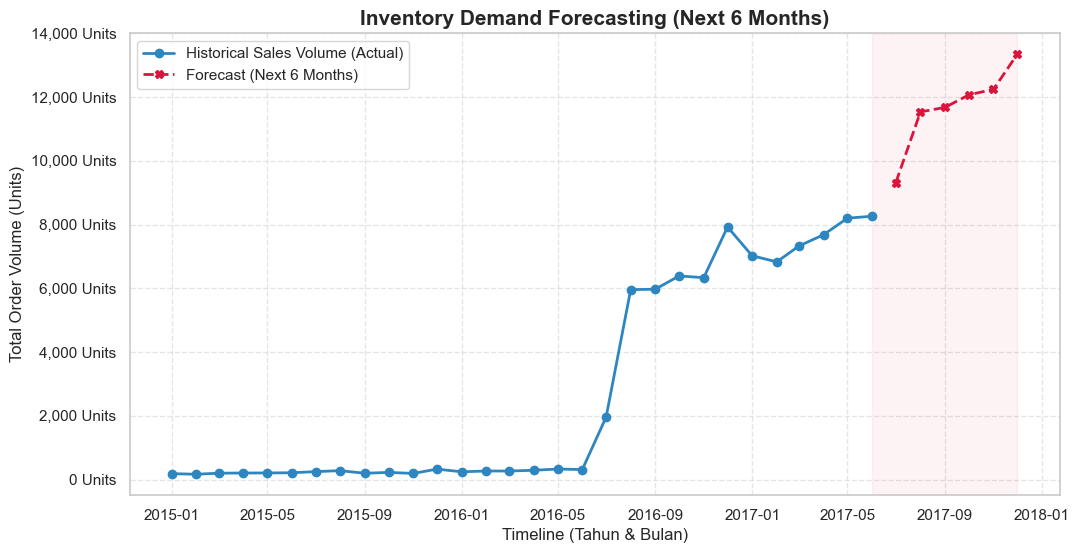

In [59]:
# Menggabungkan kolom 'year' dan 'month' menjadi satu format Datetime yang valid (Tanggal diset ke tanggal 1 setiap bulan)
from pyexpat import model


df_trend['order_date'] = pd.to_datetime({'year':df_trend['year'], 'month':df_trend['month'], 'day':1})

# Menggabungkan penjualan berdasarkan bulan dan tahun
df_monthly = df_trend.groupby('order_date')['total_volume_sold'].sum().reset_index()

# Menjadika order_date sebagai index untuk analisis time series (Syarat wajib time series)
df_monthly.set_index('order_date', inplace=True)

# Menetapkan frekuensi index sebagai bulanan
df_monthly.index.freq = 'MS'  # MS = Month Start (Awal Bulan)

print("=== 5 Baris Pertama Data Penjualan Bulanan (Siap Prediksi) ===")
display(df_monthly.head())

# Membangun model forecasting (holt-winters)
# Holt-Winters sangat baik untuk data yang memiliki tren (naik/turun) dan musiman (berulang tiap tahun)
# seasonal_periods=12 (karena pola berulang setiap 12 bulan)
model = ExponentialSmoothing(
  df_monthly['total_volume_sold'], 
  trend='add', 
  seasonal='add', 
  seasonal_periods=12)
model_fit = model.fit()

# Memprediksi kebutuhan volume pesanan untuk 6 bulan ke depan
forecast_steps = 6
forecast = model_fit.forecast(steps=forecast_steps)

# Visualisasi hasil forecasting
plt.figure(figsize=(12, 6))

# Plot data historis (Data Asli)
plt.plot(
df_monthly.index,
df_monthly['total_volume_sold'],
label='Historical Sales Volume (Actual)',
marker='o',
color='#2E86C1',
linewidth=2
)

# Plot data prediksi (Data Masa Depan)
plt.plot(
forecast.index,
forecast,
label='Forecast (Next 6 Months)',
marker='X',
color='crimson',
linewidth=2,
linestyle='--'
)

# Mempercantik grafik
plt.title('Inventory Demand Forecasting (Next 6 Months)', fontsize=15, fontweight='bold')
plt.xlabel('Timeline (Tahun & Bulan)', fontsize=12)
plt.ylabel('Total Order Volume (Units)', fontsize=12)

# Menambah Grid & Label
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left',fontsize=11)

# Format Sumbu Y agar rapi (misal: 1,000 Units)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{int(y):,} Units'))

# Menandai area prediksi dengan blok warna arsiran yang elegan
plt.axvspan(
df_monthly.index[-1],  # Awal area prediksi (bulan terakhir data historis)
forecast.index[-1],     # Akhir area prediksi (bulan terakhir prediksi)
color='crimson',
alpha=0.05,
label='Forecasting Zone'
)

In [67]:
# # MENAMPILKAN HASIL PREDIKSI DALAM BENTUK TABEL
# # Mengubah data forecast (yang tadinya berupa Series) menjadi DataFrame agar rapi seperti tabel
# df_forecast = pd.DataFrame(forecast, columns=['Prediksi Volume Pesanan (Units)'])

# # Membulatkan angka ke integer (karena pesanan barang tidak mungkin bernilai desimal atau pecahan)
# df_forecast['Prediksi Volume Pesanan (Units)'] = df_forecast['Prediksi Volume Pesanan (Units)'].round().astype(int)

# Memberi nama pada kolom index agar lebih jelas
df_forecast.index.name = 'Periode (Tahun-Bulan)'

# Menampilkan data prediksi dalam bentuk tabel
print("=== TABEL PREDIKSI VOLUME PESANAN (6 BULAN KE DEPAN) ===")
display(df_forecast)

=== TABEL PREDIKSI VOLUME PESANAN (6 BULAN KE DEPAN) ===


,Prediksi Volume Pesanan (Units)
Periode (Tahun-Bulan),
2017-07-01,9317
2017-08-01,11533
2017-09-01,11676
2017-10-01,12068
2017-11-01,12243
2017-12-01,13342
